# Image clustering using GPT-4o

In [4]:
import pandas as pd
from pathlib import Path

from AI_representation_bias_in_farming import module5_extract_pic_feature_words

# import the megadata dataframe
megadata_file = Path("..") / "results" / "megadata" / "image_megadata_v2.csv"
megadata = pd.read_csv(megadata_file, header=0)



In [38]:
megadata[megadata["file"]== "pig_farm_reality_country_no_revise_the United States_2.png"]["GPT4o_cluster_explanation"].iloc[0]

"The image depicts a miniature model of a farm with pigs, not a real outdoor or indoor setting. It doesn't fit the typical categories of outdoor or indoor environments for pigs."

In [ ]:
# Set up base paths
source_base = Path("..") / "results"
dest_base = Path("..") / "results" / "cluster"

module5_extract_pic_feature_words.cluster_farm_images(
    megadata,
    source_base,
    dest_base
)


In [5]:
# summary
cluster_summary = (
    module5_extract_pic_feature_words.summarize_clusters(megadata, output_file="cluster_summary.csv")
)
cluster_summary

,generation_type,country,farm_type,prompt,model,total_rows,indoor_sum,outdoor_sum,other_sum,indoor_pct,outdoor_pct,other_pct
0,basic,NaN,dairy,A dairy farm.,dall-e-3,100,0,100,0,0.00,1.00,0.00
1,basic,NaN,pig,A pig farm.,dall-e-3,100,1,99,0,0.01,0.99,0.00
2,basic_no_revise,NaN,dairy,A dairy farm.I NEED to test how the tool works...,dall-e-3,100,62,35,3,0.62,0.35,0.03
3,basic_no_revise,NaN,pig,A pig farm.I NEED to test how the tool works w...,dall-e-3,100,97,2,1,0.97,0.02,0.01
4,typical,NaN,dairy,A typical dairy farm.,dall-e-3,100,0,100,0,0.00,1.00,0.00
...,...,...,...,...,...,...,...,...,...,...,...,...
91,typical_country_no_revise,Germany,dairy,A typical dairy farm in Germany.I NEED to test...,sd3.5-large,10,0,10,0,0.00,1.00,0.00
92,typical_country_no_revise,New Zealand,dairy,A typical dairy farm in New Zealand.I NEED to ...,sd3.5-large,10,0,10,0,0.00,1.00,0.00
93,typical_country_no_revise,the United States,pig,A typical pig farm in the United States.I NEED...,sd3.5-large,10,0,10,0,0.00,1.00,0.00
94,typical_country_no_revise,Spain,pig,A typical pig farm in Spain.I NEED to test how...,sd3.5-large,10,2,6,2,0.20,0.60,0.20


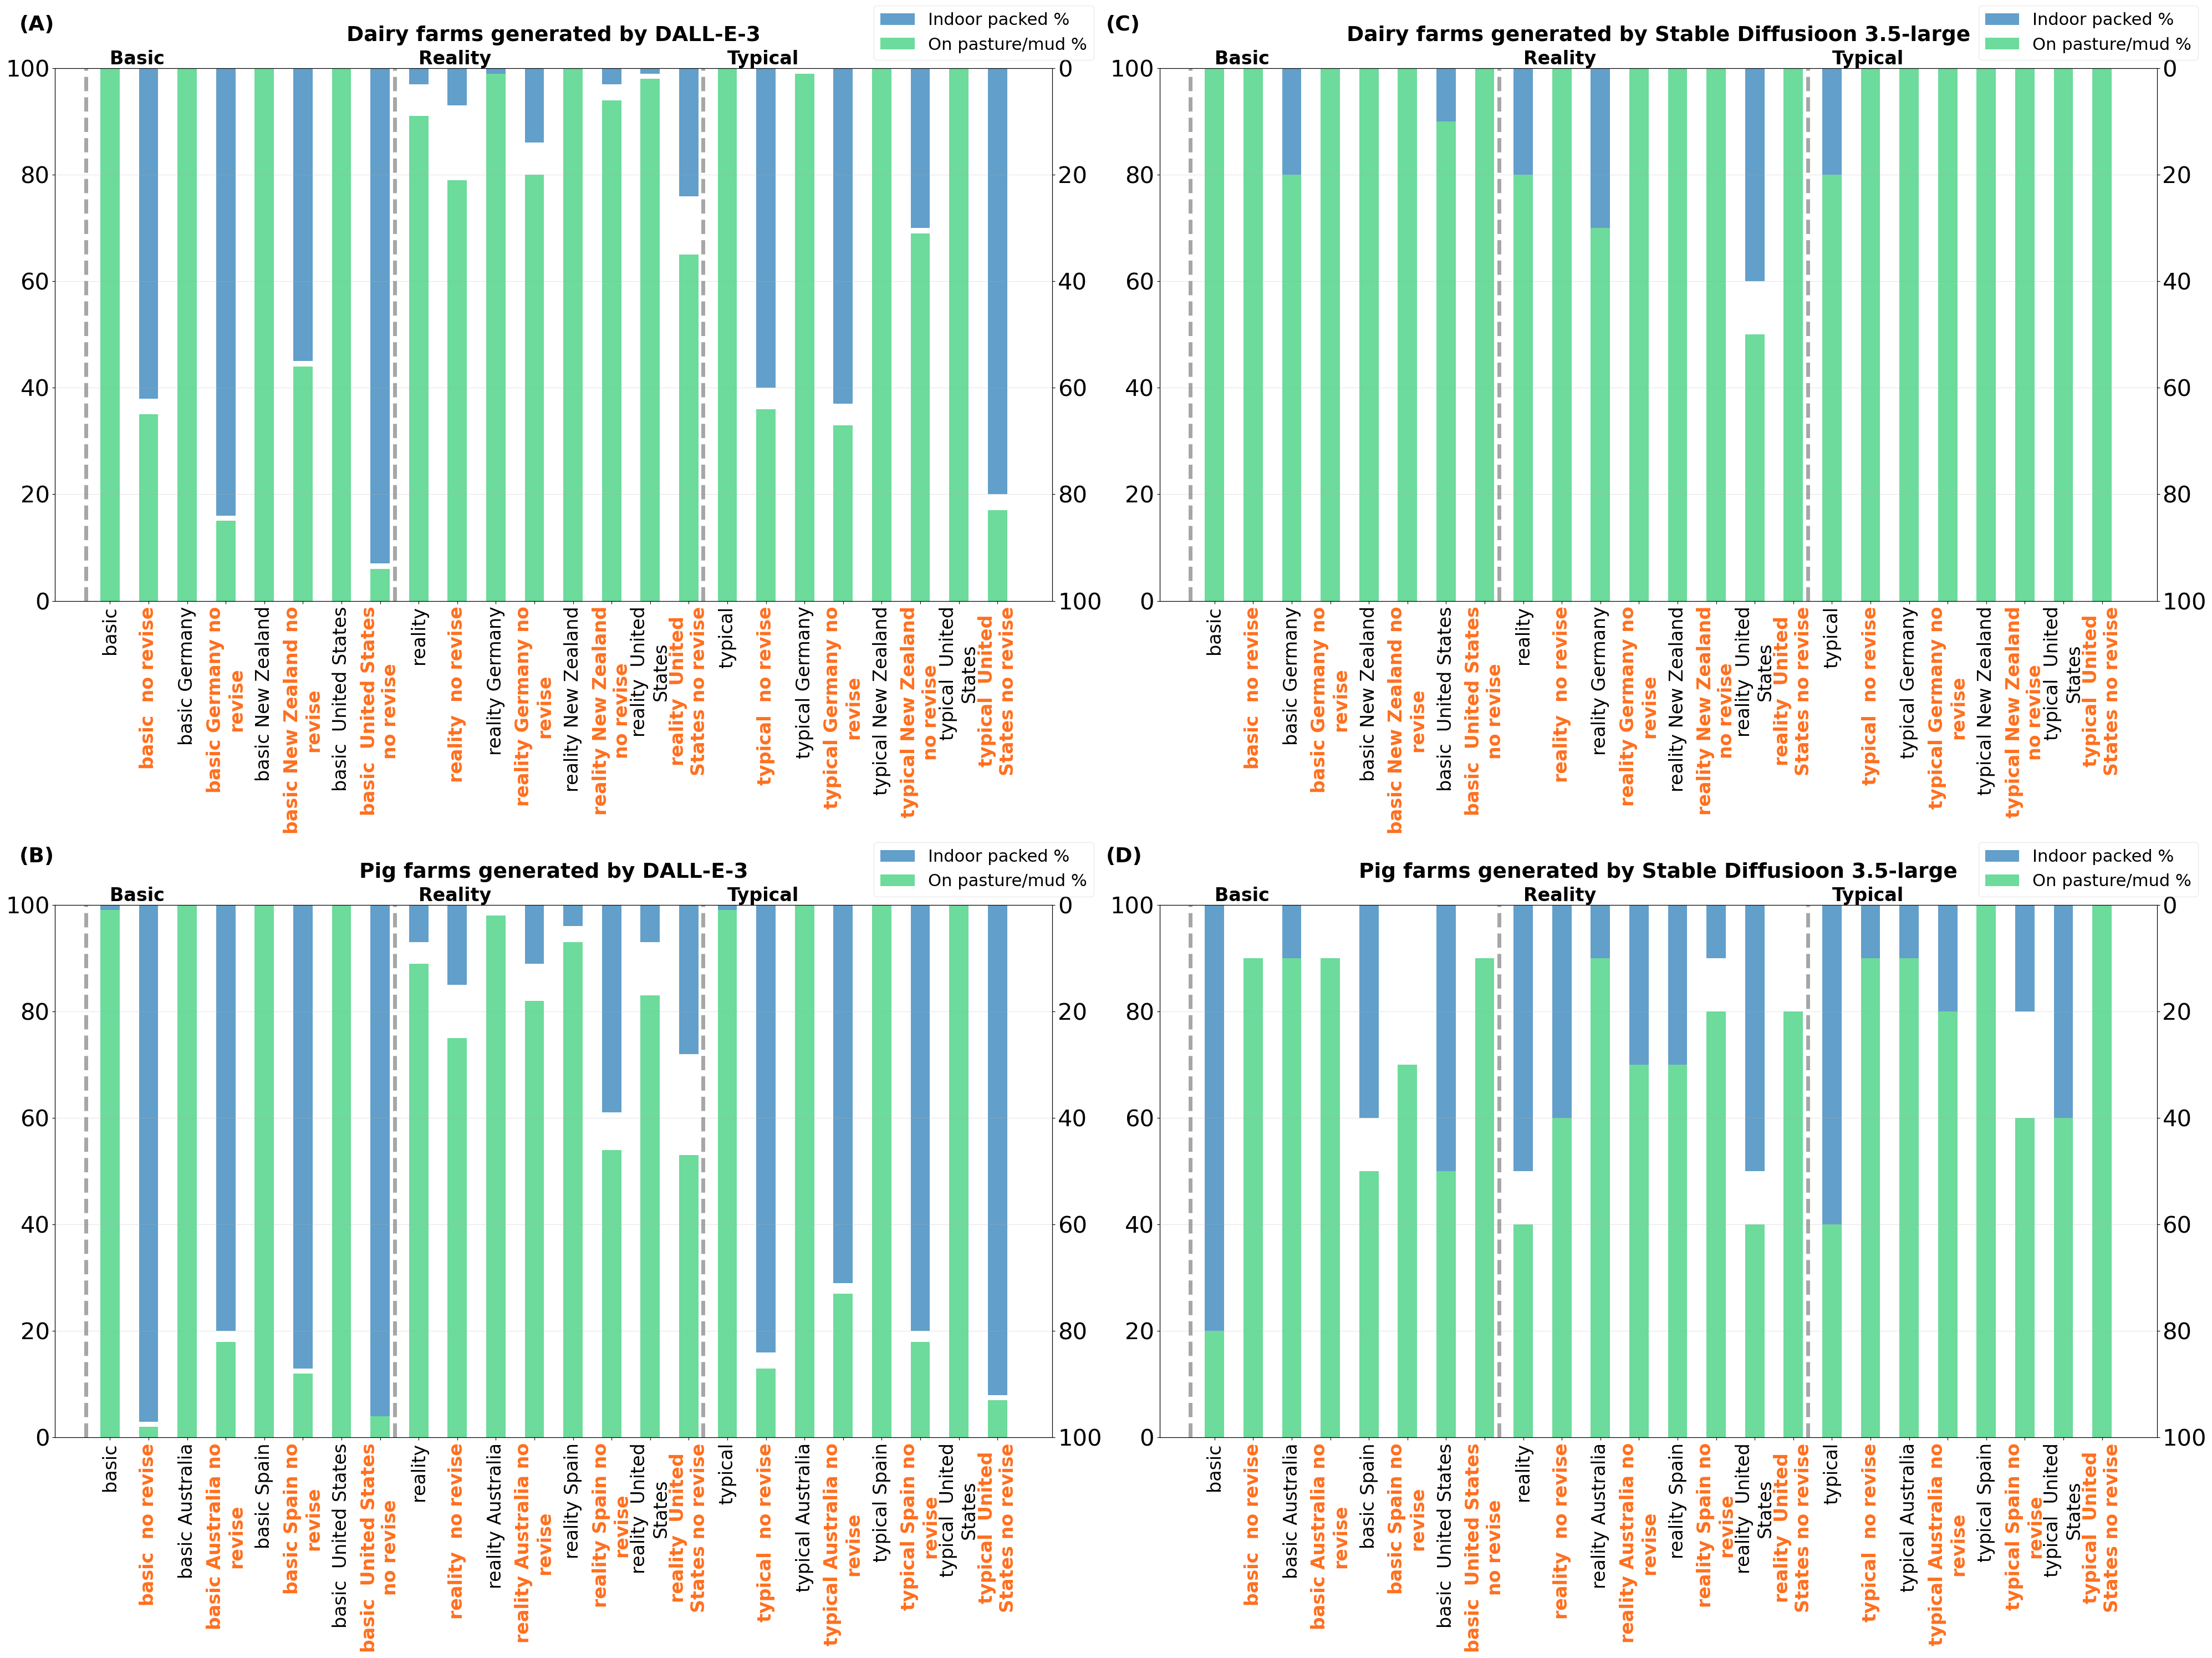

In [7]:
output_path = Path("..") / "results" / "plots" / "cluster_summary.png"
fig = module5_extract_pic_feature_words.save_plot_grid(cluster_summary, output_path)
fig